In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customer_data = pd.read_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv"
)

clv_results = pd.read_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_predictions.csv"
)

customer_data = customer_data.merge(
    clv_results[[
        "CustomerID",
        "CLVSegment"
    ]],
    on="CustomerID",
    how="left"
)

In [ ]:
customer_data["LogFrequency"] = np.log1p(
    customer_data["Frequency"]
)

customer_data["LogMonetaryValue"] = np.log1p(
    customer_data["MonetaryValue"].clip(lower=0)
)

customer_data["LogAverageOrderValue"] = np.log1p(
    customer_data["AverageOrderValue"].clip(lower=0)
)

customer_data["LogTotalQuantity"] = np.log1p(
    customer_data["TotalQuantity"].clip(lower=0)
)

customer_data["LogProductDiversity"] = np.log1p(
    customer_data["ProductDiversity"].clip(lower=0)
)

pca_features = [
    "RecencyDays",
    "LogFrequency",
    "LogMonetaryValue",
    "LogAverageOrderValue",
    "LogTotalQuantity",
    "LogProductDiversity"
]

X_pca = customer_data[pca_features].copy()

### Principal Component Analysis

Principal Component Analysis reduces several correlated customer variables into a smaller number of uncorrelated components. Each component is a weighted combination of the original variables:

$$
PC_k=w_{k1}Z_1+w_{k2}Z_2+\cdots+w_{kp}Z_p
$$

The first component explains the largest possible amount of variation. Each subsequent component explains the greatest remaining variation while remaining uncorrelated with the previous components. The variables are standardised before PCA because they are measured on different scales.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_pca_scaled = scaler.fit_transform(
    X_pca
)

pca = PCA()

pca_scores = pca.fit_transform(
    X_pca_scaled
)

In [ ]:
explained_variance = pd.DataFrame({
    "Component": [
        f"PC{i+1}"
        for i in range(len(pca_features))
    ],
    "ExplainedVariance": (
        pca.explained_variance_ratio_
    ),
    "CumulativeVariance": np.cumsum(
        pca.explained_variance_ratio_
    )
})

explained_variance.round(4)

,Component,ExplainedVariance,CumulativeVariance
0,PC1,0.6497,0.6497
1,PC2,0.1575,0.8072
2,PC3,0.1069,0.9142
3,PC4,0.0644,0.9786
4,PC5,0.0209,0.9995
5,PC6,0.0005,1.0000


In [ ]:
components_for_80 = (
    np.argmax(
        explained_variance[
            "CumulativeVariance"
        ].values >= 0.80
    ) + 1
)

print(
    "Components required for 80% variance:",
    components_for_80
)

Components required for 80% variance: 2


In [ ]:
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=pca_features,
    columns=["PC1", "PC2"]
)

loadings.round(4)

,PC1,PC2
RecencyDays,-0.2767,0.5998
LogFrequency,0.4129,-0.3760
LogMonetaryValue,0.4906,0.1310
LogAverageOrderValue,0.3370,0.6818
LogTotalQuantity,0.4760,0.1128
LogProductDiversity,0.4150,-0.0639


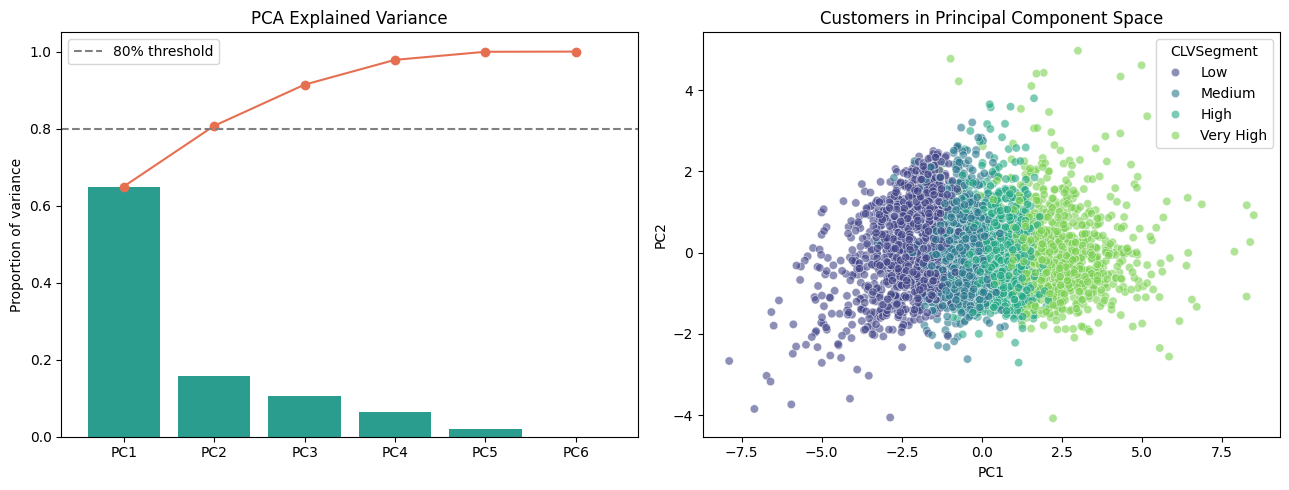

In [ ]:
customer_data["PC1"] = pca_scores[:, 0]
customer_data["PC2"] = pca_scores[:, 1]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# Scree plot
axes[0].bar(
    explained_variance["Component"],
    explained_variance["ExplainedVariance"],
    color="#2A9D8F"
)

axes[0].plot(
    explained_variance["Component"],
    explained_variance["CumulativeVariance"],
    marker="o",
    color="#E76F51"
)

axes[0].axhline(
    0.80,
    linestyle="--",
    color="grey",
    label="80% threshold"
)

axes[0].set_ylabel("Proportion of variance")
axes[0].set_title("PCA Explained Variance")
axes[0].legend()

# PCA customer map
sns.scatterplot(
    data=customer_data,
    x="PC1",
    y="PC2",
    hue="CLVSegment",
    hue_order=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    alpha=0.6,
    palette="viridis",
    ax=axes[1]
)

axes[1].set_title(
    "Customers in Principal Component Space"
)

plt.tight_layout()
plt.savefig(
    "pca_customer_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### PCA Results and Interpretation

The first principal component explained 64.97% of the total variation, while the second explained 15.75%. Together, the first two components explained 80.72% of the variation in the six customer variables. Therefore, the original six-dimensional customer dataset can be represented using two components while retaining more than 80% of its information.

PC1 had positive loadings for frequency, monetary value, average order value, total quantity and product diversity, together with a negative loading for recency days. Therefore, PC1 represents overall customer engagement and value. Customers with higher PC1 scores generally purchased more frequently, spent more, purchased more products and made more recent purchases.

PC2 had its strongest positive loadings for average order value and recency days, together with a negative loading for frequency. It primarily distinguishes customers who place larger but less frequent orders from customers who purchase more frequently.

The PCA customer map shows that CLV segments are mainly separated along PC1. Low-value customers generally have lower PC1 scores, while very-high-value customers have higher PC1 scores. This supports the CLV segmentation because higher customer value corresponds to stronger historical purchasing behaviour.
